# Feature Engineering — Pipeline de Features para Inadimplência

Este notebook aplica o pipeline de feature engineering implementado em `src/feature_engineering.py` às bases de desenvolvimento e teste, e valida o resultado antes de seguir para a modelagem.

Verificamos, em particular:
1. Que o pipeline roda sem erros para treino (desenvolvimento) e teste;
2. A qualidade das features geradas (shape, nulos, estatísticas descritivas);
3. Que **não há vazamento de dados (data leakage)** — nenhuma feature comportamental usa informação do próprio mês (safra) ou de safras futuras.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import build_features, read_csv_semicolon

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = "../data"


## 1. Carregamento das bases e execução do pipeline

O pipeline recebe as quatro bases já carregadas (`sep=";"`) e é chamado duas vezes:

- **Treino:** `build_features(cadastral, info, pagamentos_dev, pagamentos_dev)` — o próprio histórico de desenvolvimento serve de fonte para as features comportamentais de cada linha (usando apenas safras anteriores à da própria linha).
- **Teste:** `build_features(cadastral, info, pagamentos_dev, pagamentos_teste)` — o histórico ainda vem de `pagamentos_dev` (a única base com desfecho conhecido), já que todas as safras de desenvolvimento são anteriores às safras de teste.

In [2]:
df_cadastral = read_csv_semicolon(f"{DATA_DIR}/base_cadastral.csv")
df_info = read_csv_semicolon(f"{DATA_DIR}/base_info.csv")
df_pag_dev = read_csv_semicolon(f"{DATA_DIR}/base_pagamentos_desenvolvimento.csv")
df_pag_test = read_csv_semicolon(f"{DATA_DIR}/base_pagamentos_teste.csv")

feat_dev = build_features(df_cadastral, df_info, df_pag_dev, df_pag_dev)
feat_test = build_features(df_cadastral, df_info, df_pag_dev, df_pag_test)

print("Features de treino (dev):", feat_dev.shape)
print("Features de teste:", feat_test.shape)

Features de treino (dev): (77414, 25)
Features de teste: (12275, 25)


### 1.1 Consistência de linhas

O pipeline deve gerar **exatamente uma linha de features por linha de entrada**, na mesma ordem — não há deduplicação nem explosão de linhas, mesmo quando um cliente tem múltiplas cobranças na mesma safra.

In [3]:
assert feat_dev.shape[0] == df_pag_dev.shape[0], "Número de linhas de treino não bate com a base de origem"
assert feat_test.shape[0] == df_pag_test.shape[0], "Número de linhas de teste não bate com a base de origem"
assert (feat_dev.index == df_pag_dev.index).all(), "Índice de treino não está alinhado com a base de origem"
assert (feat_test.index == df_pag_test.index).all(), "Índice de teste não está alinhado com a base de origem"
print("OK: uma linha de features por linha de entrada, na mesma ordem, em treino e teste.")

OK: uma linha de features por linha de entrada, na mesma ordem, em treino e teste.


## 2. Visão Geral das Features

### 2.1 Treino (desenvolvimento)

In [4]:
display(feat_dev.head())
print(feat_dev.dtypes)

,ID_CLIENTE,SAFRA_REF,flag_pf,porte_encoded,segmento_freq,dominio_freq,cep_freq,ddd_freq,meses_desde_cadastro,renda_mes_anterior,no_funcionarios,qtd_pagamentos_anteriores,qtd_inadimplencias_anteriores,flag_cliente_novo,taxa_inadimplencia_hist,media_atraso_dias,std_atraso_dias,max_atraso_dias,valor_medio_hist,taxa_media_hist,valor_a_pagar,taxa,dia_vencimento,dias_emissao_vencimento,ratio_valor_renda
0,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,35516.41,6.99,6,20,NaN
1,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,17758.21,6.99,10,22,NaN
2,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,17431.96,6.99,17,22,NaN
3,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1341.00,6.99,5,36,NaN
4,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,21309.85,6.99,20,20,NaN


ID_CLIENTE                         int64
SAFRA_REF                            str
flag_pf                            int64
porte_encoded                      int64
segmento_freq                    float64
dominio_freq                     float64
cep_freq                         float64
ddd_freq                         float64
meses_desde_cadastro               int32
renda_mes_anterior               float64
no_funcionarios                  float64
qtd_pagamentos_anteriores          int64
qtd_inadimplencias_anteriores      int64
flag_cliente_novo                  int64
taxa_inadimplencia_hist          float64
media_atraso_dias                float64
std_atraso_dias                  float64
max_atraso_dias                  float64
valor_medio_hist                 float64
taxa_media_hist                  float64
valor_a_pagar                    float64
taxa                             float64
dia_vencimento                     int32
dias_emissao_vencimento            int64
ratio_valor_rend

### 2.2 Teste

In [5]:
display(feat_test.head())
print(feat_test.dtypes)

,ID_CLIENTE,SAFRA_REF,flag_pf,porte_encoded,segmento_freq,dominio_freq,cep_freq,ddd_freq,meses_desde_cadastro,renda_mes_anterior,no_funcionarios,qtd_pagamentos_anteriores,qtd_inadimplencias_anteriores,flag_cliente_novo,taxa_inadimplencia_hist,media_atraso_dias,std_atraso_dias,max_atraso_dias,valor_medio_hist,taxa_media_hist,valor_a_pagar,taxa,dia_vencimento,dias_emissao_vencimento,ratio_valor_renda
0,5058298901476893676,2021-07,0.0,1.0,0.408279,0.303502,0.014449,0.021336,88.0,467430.0,NaN,54,0,0,0.000000,0.055556,0.711540,3.0,11262.844340,6.286296,11204.75,4.99,4,21,0.023971
1,274692171162531764,2021-07,0.0,0.0,0.408279,0.303502,0.065399,0.046382,191.0,417192.0,104.0,230,6,0,0.026087,0.321739,10.625871,109.0,34999.194956,7.268261,60718.50,5.99,23,46,0.145541
2,274692171162531764,2021-07,0.0,0.0,0.408279,0.303502,0.065399,0.046382,191.0,417192.0,104.0,230,6,0,0.026087,0.321739,10.625871,109.0,34999.194956,7.268261,60718.50,5.99,25,45,0.145541
3,274692171162531764,2021-07,0.0,0.0,0.408279,0.303502,0.065399,0.046382,191.0,417192.0,104.0,230,6,0,0.026087,0.321739,10.625871,109.0,34999.194956,7.268261,62250.00,5.99,30,45,0.149212
4,465309249432033993,2021-07,0.0,2.0,0.349838,0.303502,0.012167,0.012059,84.0,873938.0,119.0,139,0,0,0.000000,-0.122302,0.664421,1.0,19568.377059,7.018777,26593.95,6.99,30,25,0.030430


ID_CLIENTE                         int64
SAFRA_REF                            str
flag_pf                          float64
porte_encoded                    float64
segmento_freq                    float64
dominio_freq                     float64
cep_freq                         float64
ddd_freq                         float64
meses_desde_cadastro             float64
renda_mes_anterior               float64
no_funcionarios                  float64
qtd_pagamentos_anteriores          int64
qtd_inadimplencias_anteriores      int64
flag_cliente_novo                  int64
taxa_inadimplencia_hist          float64
media_atraso_dias                float64
std_atraso_dias                  float64
max_atraso_dias                  float64
valor_medio_hist                 float64
taxa_media_hist                  float64
valor_a_pagar                    float64
taxa                             float64
dia_vencimento                     int32
dias_emissao_vencimento            int64
ratio_valor_rend

### 2.3 Nulos por feature (treino vs. teste)

Colunas de contagem/flag comportamentais (`qtd_*`, `flag_cliente_novo`) nunca são nulas — clientes sem histórico recebem 0 e a flag correspondente. Já as taxas/médias históricas (`taxa_inadimplencia_hist`, `media_atraso_dias`, etc.) são nulas exatamente para quem não tem nenhuma transação anterior, o que é o comportamento esperado.

In [6]:
nulls_dev = feat_dev.isnull().sum().rename("n_nulos_treino")
pct_dev = (feat_dev.isnull().mean() * 100).round(2).rename("pct_nulos_treino")
nulls_test = feat_test.isnull().sum().rename("n_nulos_teste")
pct_test = (feat_test.isnull().mean() * 100).round(2).rename("pct_nulos_teste")

null_summary = pd.concat([nulls_dev, pct_dev, nulls_test, pct_test], axis=1)
display(null_summary)

,n_nulos_treino,pct_nulos_treino,n_nulos_teste,pct_nulos_teste
ID_CLIENTE,0,0.00,0,0.00
SAFRA_REF,0,0.00,0,0.00
flag_pf,0,0.00,38,0.31
porte_encoded,0,0.00,38,0.31
segmento_freq,0,0.00,38,0.31
dominio_freq,0,0.00,38,0.31
cep_freq,0,0.00,38,0.31
ddd_freq,0,0.00,38,0.31
meses_desde_cadastro,0,0.00,38,0.31
renda_mes_anterior,6132,7.92,726,5.91


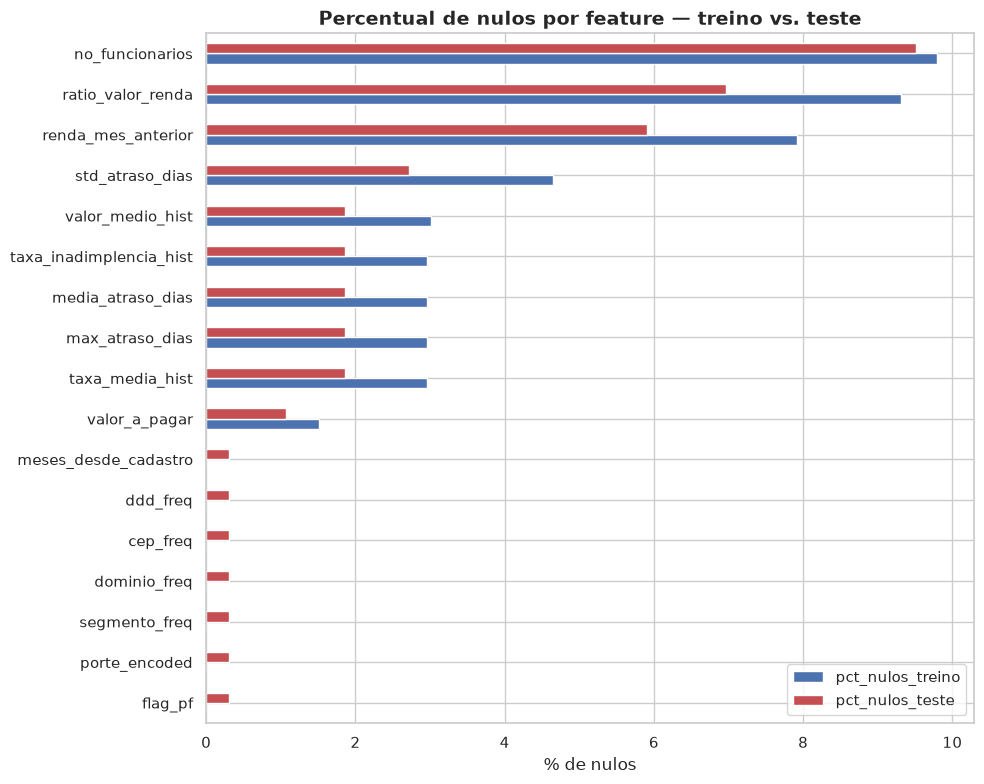

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = null_summary[["pct_nulos_treino", "pct_nulos_teste"]].sort_values("pct_nulos_treino", ascending=True)
plot_df = plot_df[(plot_df["pct_nulos_treino"] > 0) | (plot_df["pct_nulos_teste"] > 0)]
plot_df.plot(kind="barh", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Percentual de nulos por feature — treino vs. teste")
ax.set_xlabel("% de nulos")
plt.tight_layout()
plt.show()

### 2.4 Estatísticas descritivas

In [8]:
display(feat_dev.drop(columns=["ID_CLIENTE", "SAFRA_REF"]).describe().T)

,count,mean,std,min,25%,50%,75%,max
flag_pf,77414.0,0.002829,0.053113,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
porte_encoded,77414.0,1.104671,0.835700,-1.000000e+00,1.000000,1.000000,2.000000,2.000000e+00
segmento_freq,77414.0,0.343198,0.078714,0.000000e+00,0.349838,0.349838,0.408279,4.082792e-01
dominio_freq,77414.0,0.251792,0.090345,0.000000e+00,0.251362,0.303502,0.305058,3.050584e-01
cep_freq,77414.0,0.017866,0.014196,7.604563e-04,0.009125,0.015209,0.019772,6.539924e-02
ddd_freq,77414.0,0.027327,0.033273,0.000000e+00,0.008349,0.016698,0.030612,1.159555e-01
meses_desde_cadastro,77414.0,117.880771,74.581180,-1.000000e+00,60.000000,102.000000,179.000000,2.500000e+02
renda_mes_anterior,71282.0,291438.084103,213293.159141,1.050000e+02,134074.250000,240502.000000,396250.000000,1.682759e+06
no_funcionarios,69827.0,117.692812,18.779624,0.000000e+00,105.000000,118.000000,130.000000,1.980000e+02
qtd_pagamentos_anteriores,77414.0,98.944945,137.986363,0.000000e+00,21.000000,56.000000,114.000000,1.123000e+03


In [9]:
display(feat_test.drop(columns=["ID_CLIENTE", "SAFRA_REF"]).describe().T)

,count,mean,std,min,25%,50%,75%,max
flag_pf,12237.0,0.003841,0.061858,0.000000,0.000000,0.000000,0.000000,1.000000e+00
porte_encoded,12237.0,1.105581,0.831682,-1.000000,1.000000,1.000000,2.000000,2.000000e+00
segmento_freq,12237.0,0.341638,0.077594,0.000000,0.349838,0.349838,0.408279,4.082792e-01
dominio_freq,12237.0,0.255404,0.089413,0.000000,0.251362,0.303502,0.305058,3.050584e-01
cep_freq,12237.0,0.017835,0.014121,0.000760,0.009125,0.015209,0.019772,6.539924e-02
ddd_freq,12237.0,0.027434,0.033288,0.000000,0.007421,0.016698,0.030612,1.159555e-01
meses_desde_cadastro,12237.0,127.564436,77.583341,0.000000,68.000000,125.000000,179.000000,2.550000e+02
renda_mes_anterior,11549.0,296458.185297,217813.117119,927.000000,137543.000000,249907.000000,397263.000000,1.564439e+06
no_funcionarios,11108.0,125.934912,18.884117,0.000000,114.000000,126.000000,138.000000,1.820000e+02
qtd_pagamentos_anteriores,12275.0,177.704847,209.935285,0.000000,62.000000,115.000000,207.000000,1.151000e+03


### 2.5 Novos clientes (`flag_cliente_novo`)

Verificamos a proporção de linhas sem qualquer histórico anterior — o cenário mais desafiador para o modelo, em que as features comportamentais não estão disponíveis.

In [10]:
for nome, df in [("treino", feat_dev), ("teste", feat_test)]:
    pct_novo = df["flag_cliente_novo"].mean() * 100
    print(f"{nome}: {pct_novo:.2f}% das linhas são de clientes sem histórico anterior (flag_cliente_novo=1)")

treino: 2.96% das linhas são de clientes sem histórico anterior (flag_cliente_novo=1)
teste: 1.86% das linhas são de clientes sem histórico anterior (flag_cliente_novo=1)


## 3. Verificação de Ausência de Vazamento de Dados (Data Leakage)

Reconstruímos a variável-alvo (`inadimplente`) a partir de `base_pagamentos_desenvolvimento`, exatamente como no notebook de EDA, e checamos três coisas:

1. Nenhuma feature tem correlação artificialmente perfeita (ou quase perfeita) com o alvo — o que indicaria que alguma informação do próprio desfecho vazou para dentro das features.
2. As contagens comportamentais (`qtd_pagamentos_anteriores`) crescem de forma estritamente monotônica e não-decrescente ao longo das safras de um mesmo cliente — nunca "veem" uma transação da própria safra atual ou de safras futuras.
3. Para a primeira transação de cada cliente (sem histórico algum), as features de taxa/média comportamentais são nulas e `flag_cliente_novo = 1`, nunca um valor calculado a partir do próprio desfecho da transação atual.

In [11]:
df_target = df_pag_dev.copy()
df_target["DATA_PAGAMENTO"] = pd.to_datetime(df_target["DATA_PAGAMENTO"])
df_target["DATA_VENCIMENTO"] = pd.to_datetime(df_target["DATA_VENCIMENTO"])
df_target["dias_atraso"] = (df_target["DATA_PAGAMENTO"] - df_target["DATA_VENCIMENTO"]).dt.days
df_target["inadimplente"] = (
    (df_target["dias_atraso"] >= 5) | df_target["DATA_PAGAMENTO"].isna()
).astype(int)

y = df_target["inadimplente"]
print("Taxa de inadimplência (treino):", f"{y.mean()*100:.2f}%")

Taxa de inadimplência (treino): 7.02%


### 3.1 Correlação de cada feature com o alvo

In [12]:
X_num = feat_dev.drop(columns=["ID_CLIENTE", "SAFRA_REF"])
corr_target = X_num.corrwith(y).sort_values(key=np.abs, ascending=False)
display(corr_target.to_frame("correlacao_com_alvo"))

LEAKAGE_THRESHOLD = 0.9
suspeitas = corr_target[corr_target.abs() >= LEAKAGE_THRESHOLD]
if len(suspeitas) == 0:
    print(f"OK: nenhuma feature com |correlação| >= {LEAKAGE_THRESHOLD} com o alvo. Maior correlação observada:")
    print(f"  {corr_target.index[0]} = {corr_target.iloc[0]:.3f}")
else:
    print("ATENÇÃO — possível vazamento de dados nas seguintes features:")
    display(suspeitas)

,correlacao_com_alvo
taxa_inadimplencia_hist,0.470876
qtd_inadimplencias_anteriores,0.262810
max_atraso_dias,0.224685
media_atraso_dias,0.125307
std_atraso_dias,0.114432
dias_emissao_vencimento,0.106617
valor_a_pagar,-0.088203
valor_medio_hist,-0.081799
porte_encoded,-0.078642
renda_mes_anterior,-0.067847


OK: nenhuma feature com |correlação| >= 0.9 com o alvo. Maior correlação observada:
  taxa_inadimplencia_hist = 0.471


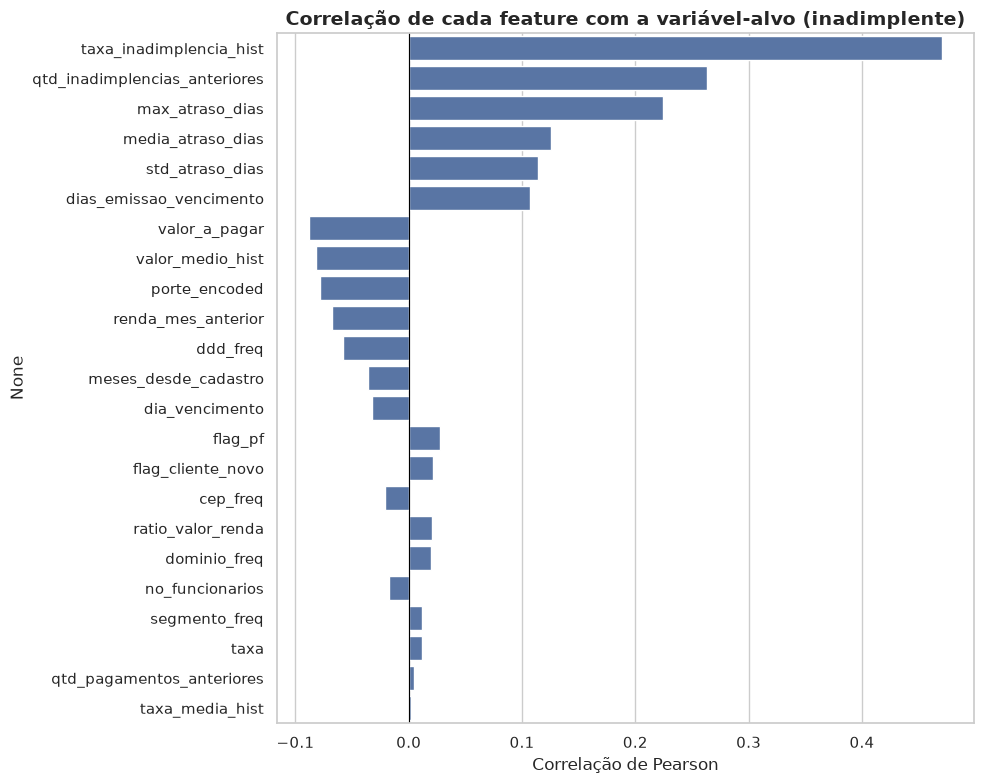

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, ax=ax, color="#4C72B0")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de cada feature com a variável-alvo (inadimplente)")
ax.set_xlabel("Correlação de Pearson")
plt.tight_layout()
plt.show()

### 3.2 Crescimento monotônico do histórico por cliente

Escolhemos o cliente com mais transações na base e mostramos `qtd_pagamentos_anteriores` ao longo das safras: o valor deve apenas crescer (nunca diminuir) e nunca contar a transação da própria safra atual.

In [14]:
cliente_top = df_pag_dev["ID_CLIENTE"].value_counts().index[0]
mask = df_pag_dev["ID_CLIENTE"] == cliente_top

historico_cliente = (
    pd.DataFrame(
        {
            "SAFRA_REF": df_pag_dev.loc[mask, "SAFRA_REF"].values,
            "qtd_pagamentos_anteriores": feat_dev.loc[mask, "qtd_pagamentos_anteriores"].values,
        }
    )
    .drop_duplicates()
    .sort_values("SAFRA_REF")
    .reset_index(drop=True)
)
display(historico_cliente)

is_monotonic = historico_cliente["qtd_pagamentos_anteriores"].is_monotonic_increasing
print(f"\nqtd_pagamentos_anteriores é não-decrescente ao longo das safras: {is_monotonic}")
assert is_monotonic, "Vazamento: contagem de histórico não é monotônica ao longo do tempo"

# Confere que, na primeira safra em que o cliente aparece, ele ainda não tem histórico
primeira_linha = historico_cliente.iloc[0]
print(f"Primeira safra do cliente ({primeira_linha['SAFRA_REF']}): "
      f"qtd_pagamentos_anteriores = {primeira_linha['qtd_pagamentos_anteriores']} (esperado: 0)")
assert primeira_linha["qtd_pagamentos_anteriores"] == 0

,SAFRA_REF,qtd_pagamentos_anteriores
0,2018-08,0
1,2018-09,14
2,2018-10,59
3,2018-11,92
4,2018-12,124
5,2019-01,150
6,2019-02,188
7,2019-03,207
8,2019-04,236
9,2019-05,266



qtd_pagamentos_anteriores é não-decrescente ao longo das safras: True
Primeira safra do cliente (2018-08): qtd_pagamentos_anteriores = 0 (esperado: 0)


### 3.3 Clientes novos não têm estatísticas comportamentais "inventadas"

Para toda linha com `flag_cliente_novo == 1`, as features de taxa/média histórica devem ser nulas (não há histórico para calculá-las) — nunca um valor implicitamente derivado do desfecho da própria transação.

In [15]:
cols_hist_rate = ["taxa_inadimplencia_hist", "media_atraso_dias", "std_atraso_dias", "max_atraso_dias", "valor_medio_hist", "taxa_media_hist"]

novos = feat_dev[feat_dev["flag_cliente_novo"] == 1]
todas_nulas = novos[cols_hist_rate].isnull().all().all()
print(f"Total de linhas de clientes novos: {len(novos)}")
print(f"Todas as features de taxa/média histórica são nulas para clientes novos: {todas_nulas}")
assert todas_nulas, "Vazamento: cliente sem histórico possui estatística comportamental calculada"

print("\nOK — nenhum indício de vazamento de dados encontrado nas verificações acima.")

Total de linhas de clientes novos: 2295
Todas as features de taxa/média histórica são nulas para clientes novos: True

OK — nenhum indício de vazamento de dados encontrado nas verificações acima.


## 4. Conclusões

- O pipeline `build_features` roda sem erros para treino e teste e produz exatamente uma linha de features por linha de entrada, preservando a ordem original.
- As únicas features com valores nulos são: `renda_mes_anterior` / `no_funcionarios` (quando não há registro em `base_info` para o par cliente/safra) e as estatísticas comportamentais de clientes sem histórico anterior — ambos os casos são nulos "genuínos" (ausência real de informação), não bugs do pipeline.
- A checagem de correlação não encontrou nenhuma feature com associação artificialmente perfeita com o alvo; a variável mais associada (`taxa_inadimplencia_hist`, a taxa de inadimplência histórica do cliente) tem correlação moderada, coerente com uma feature genuinamente preditiva e não vazada.
- As contagens de histórico crescem estritamente ao longo do tempo por cliente e são zero na primeira aparição de cada cliente, confirmando que apenas safras estritamente anteriores à safra da linha são usadas — condição central para evitar vazamento temporal.
- O pipeline está pronto para alimentar a etapa de modelagem, com a mesma função aplicável tanto ao treino quanto ao teste.